# ── Cell 1 — Configuration ─────────────────────────────────────────────

In [61]:
# Cell 1 — Configuración (zero AWS credentials)
import boto3
import requests
import json
import uuid

REGION            = "us-east-1"
COGNITO_CLIENT_ID = "1qpnps2hg98a5u0ffeg9p1df8"
USERNAME          = "testuser"
PASSWORD          = "PermanentPass1!"

AGENTCORE_ENDPOINT = (
    "https://bedrock-agentcore.us-east-1.amazonaws.com"
    "/runtimes/app_main-X3Fu7U6ukU/invocations"
    "?accountId=551670267045"
)
print("✅ Configuration loaded")

✅ Configuration loaded


In [1]:
#pip install requests boto3 python-dotenv

Note: you may need to restart the kernel to use updated packages.


# ── Cell 2 — Authenticate with Cognito ────────────────────────────────

In [ ]:
import boto3

# Inicializar el cliente de Cognito
cognito = boto3.client("cognito-idp", region_name="us-east-1")

# Cell 2 — Obtener ID Token
auth = cognito.initiate_auth(
    AuthFlow="USER_PASSWORD_AUTH",
    AuthParameters={
        "USERNAME": USERNAME, 
        "PASSWORD": PASSWORD
    },
    ClientId=COGNITO_CLIENT_ID,
)

id_token = auth["AuthenticationResult"]["IdToken"]
print("✅ Token obtenido")

✅ Token obtenido


# ── Cell 3 — Query helper ──────────────────────────────────────────────

In [63]:
# Cell 3 — Query helper (HTTPS directo, sin AWS credentials)
def query_agent(question: str):
    print(f"\n{'='*60}")
    print(f"🔍 Query: {question}")
    print('='*60)

    # Cell 3 — usar id_token (tiene claim 'aud')
    response = requests.post(
        AGENTCORE_ENDPOINT,
        headers={
            "Authorization": f"Bearer {id_token}",
            "Content-Type":  "application/json",
        },
        json={"query": question, "session_id": str(uuid.uuid4())},
        timeout=120,
    )

    print(f"HTTP Status: {response.status_code}")

    if response.status_code != 200:
        print(f"❌ Error: {response.text[:500]}")
        return

    result = response.json()

    for chunk in result.get("events", []):
        event_type = chunk.get("event")
        if event_type == "tool_call":
            print(f"\n🔧 Tool Called: {chunk['tool']}")
            print(f"   Args: {chunk['args']}")
        elif event_type == "tool_result":
            print(f"\n📦 Tool Result ({chunk['tool']}):")
            print(f"   {chunk['content'][:200]}")
        elif event_type == "ai_response":
            print(f"\n🤖 Agent Response:\n{chunk['content']}")

    print(f"\n✅ Session: {result.get('session_id')}")
    print(f"   Trace:   {result.get('trace_id')}")

# Cell 5 — Query 1: Current stock price

In [64]:
query_agent("What is the stock price for Amazon right now?")


🔍 Query: What is the stock price for Amazon right now?
HTTP Status: 200

🔧 Tool Called: retrieve_realtime_stock_price
   Args: {'ticker': 'AMZN'}

🤖 Agent Response:
I'll get the current real-time stock price for Amazon (AMZN) for you.

📦 Tool Result (retrieve_realtime_stock_price):
   📈 Amazon.com, Inc. (AMZN)
Current Price: USD 207.67
Previous Close: USD 209.53
Change: ▼ 1.86 (0.89%)
Market Cap: $2,229,321,072,640


🤖 Agent Response:
Amazon (AMZN) is currently trading at **$207.67**, down $1.86 (-0.89%) from the previous close of $209.53.

Key details:
- **Current Price**: $207.67
- **Previous Close**: $209.53
- **Daily Change**: -$1.86 (-0.89%)
- **Market Cap**: $2.23 trillion

The stock is experiencing a slight decline today, trading below yesterday's closing price.

✅ Session: 31c36da7-2dc8-4757-b9ed-fef777e753ac
   Trace:   570595ab-c9fb-4bdd-b917-5597f2f86bd3


# Cell 6 — Query 2: Q4 Historical

In [72]:
query_agent("What were the stock prices for Amazon in Q4 last year?")


🔍 Query: What were the stock prices for Amazon in Q4 last year?

🔧 Tool Called: retrieve_historical_stock_price
   Args: {'ticker': 'AMZN', 'period': '1y'}

🤖 Agent Response:
I'll retrieve Amazon's historical stock price data for Q4 of last year (which would be Q4 2023, covering October-December 2023).

📦 Tool Result (retrieve_historical_stock_price):
   📊 Historical Data for AMZN (2025-03-14 → 2026-03-13)
Opening Price: $197.41
Latest Close:  $207.67
Period High:   $258.60
Period Low:    $161.38
Average Close: $217.93
Total Change:  +5.20%

📆 Recent 

🔧 Tool Called: retrieve_historical_stock_price
   Args: {'ticker': 'AMZN', 'period': '2y'}

🤖 Agent Response:
I notice the data returned appears to be showing future dates (2025-2026), which suggests there may be an issue with the data source. Let me try retrieving a different time period to get the actual Q4 2023 data you're looking for.

📦 Tool Result (retrieve_historical_stock_price):
   📊 Historical Data for AMZN (2024-03-14 → 2026-

# Cell 7 — Query 3: Performance vs analyst predictions

In [73]:
query_agent(
    "Compare Amazon's recent stock performance to what analysts predicted in their reports"
)


🔍 Query: Compare Amazon's recent stock performance to what analysts predicted in their reports

🔧 Tool Called: retrieve_realtime_stock_price
   Args: {'ticker': 'AMZN'}

🔧 Tool Called: retrieve_historical_stock_price
   Args: {'ticker': 'AMZN', 'period': '1y'}

🔧 Tool Called: retrieve_from_knowledge_base
   Args: {'query': 'analyst predictions price targets stock performance outlook'}

🤖 Agent Response:
I'll help you compare Amazon's recent stock performance to analyst predictions. Let me gather both the current stock data and analyst predictions from Amazon's financial documents.

📦 Tool Result (retrieve_historical_stock_price):
   📊 Historical Data for AMZN (2025-03-14 → 2026-03-13)
Opening Price: $197.41
Latest Close:  $207.67
Period High:   $258.60
Period Low:    $161.38
Average Close: $217.93
Total Change:  +5.20%

📆 Recent 

📦 Tool Result (retrieve_realtime_stock_price):
   📈 Amazon.com, Inc. (AMZN)
Current Price: USD 207.67
Previous Close: USD 209.53
Change: ▼ 1.86 (0.89%)
Mark

# Cell 8 — Query 4: Current price + AI business

In [74]:
query_agent(
    "I'm researching AMZN, give me the current price and any relevant information about their AI business"
)


🔍 Query: I'm researching AMZN, give me the current price and any relevant information about their AI business

🔧 Tool Called: retrieve_realtime_stock_price
   Args: {'ticker': 'AMZN'}

🔧 Tool Called: retrieve_from_knowledge_base
   Args: {'query': 'Amazon AI business artificial intelligence strategy revenue growth AWS AI services'}

🤖 Agent Response:
I'll help you research AMZN by getting the current stock price and information about their AI business from their latest financial documents.

📦 Tool Result (retrieve_realtime_stock_price):
   📈 Amazon.com, Inc. (AMZN)
Current Price: USD 207.67
Previous Close: USD 209.53
Change: ▼ 1.86 (0.89%)
Market Cap: $2,229,321,072,640


📦 Tool Result (retrieve_from_knowledge_base):
   No relevant information found in the knowledge base.

🔧 Tool Called: retrieve_from_knowledge_base
   Args: {'query': 'AWS generative AI machine learning cloud services revenue growth'}

🤖 Agent Response:
Let me search for more specific AI-related information in Amazon'

# Cell 9 — Query 5: Office space

In [75]:
query_agent(
    "What is the total amount of office space Amazon owned in North America in 2024?"
)


🔍 Query: What is the total amount of office space Amazon owned in North America in 2024?

🔧 Tool Called: retrieve_from_knowledge_base
   Args: {'query': 'office space owned North America 2024 square feet real estate'}

🤖 Agent Response:
I'll search Amazon's financial documents to find information about their office space ownership in North America for 2024.

📦 Tool Result (retrieve_from_knowledge_base):
   No relevant information found in the knowledge base.

🔧 Tool Called: retrieve_from_knowledge_base
   Args: {'query': 'real estate properties facilities square footage North America owned leased'}

🤖 Agent Response:
Let me try a broader search for Amazon's real estate and property information:

📦 Tool Result (retrieve_from_knowledge_base):
   No relevant information found in the knowledge base.

🔧 Tool Called: retrieve_from_knowledge_base
   Args: {'query': 'facilities property plant equipment owned buildings'}

🤖 Agent Response:
Let me search for property and facilities information 

# Cell 10 — Langfuse Traces

Langfuse Traces — all queries tracked
URL: https://cloud.langfuse.com

🔍 Single trace detail — tool calls, LLM steps, latency



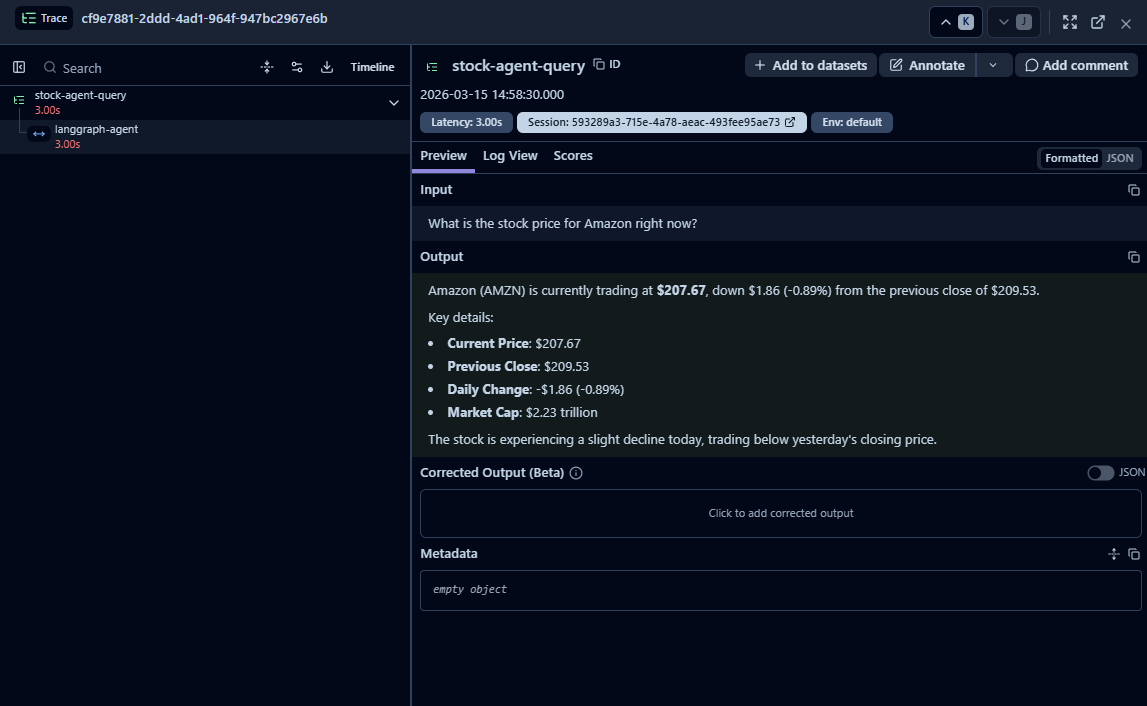

In [83]:
from IPython.display import Image, display

print("Langfuse Traces — all queries tracked")
print("URL: https://cloud.langfuse.com\n")
print("🔍 Single trace detail — tool calls, LLM steps, latency\n")
display(Image("screenshots/langfuse_traces_list.png"))

🔍 Single trace detail — tool calls, LLM steps, latency



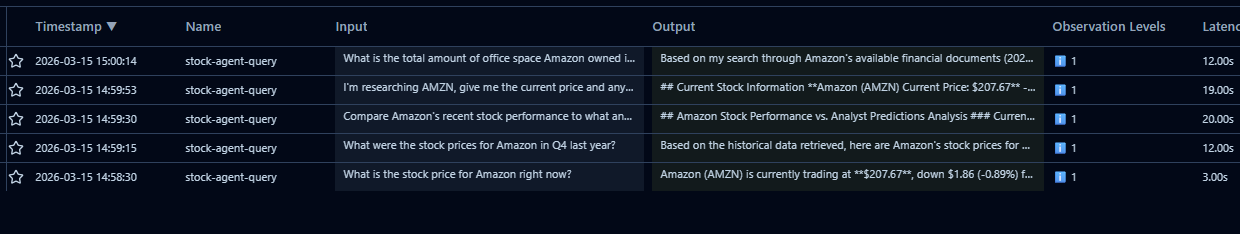

In [82]:

display(Image("screenshots/langfuse_trace_detail.png"))